In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv('data/cleaned_data.csv')

# Cell 2: predict behavior_score from IgE alone
X = df['IgE_IU_mL_log']
X = sm.add_constant(X) # adds an intercept term (required by statsmodels)
y = df['behavior_score']

model = sm.OLS(y, X).fit() # OLS = Ordinary Least Squares, the standard linear regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         behavior_score   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     45.44
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           3.29e-10
Time:                        14:52:07   Log-Likelihood:                -515.60
No. Observations:                 150   AIC:                             1035.
Df Residuals:                     148   BIC:                             1041.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.1466      2.743      0.418

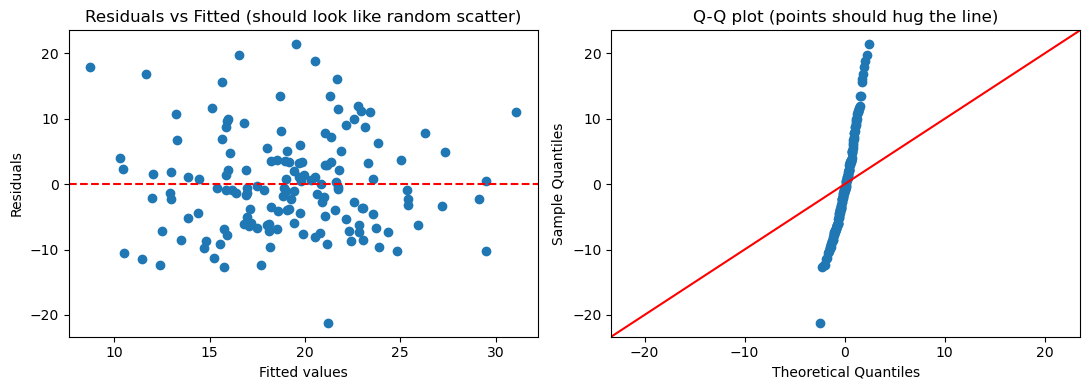

In [2]:
import matplotlib.pyplot as plt

fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].scatter(fitted, residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (should look like random scatter)')

sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('Q-Q plot (points should hug the line)')
plt.tight_layout()
plt.show()

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

log_cols = [c for c in df.columns if c.endswith('_log')]
X_multi = sm.add_constant(df[log_cols])
model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:         behavior_score   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     7.954
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           2.07e-07
Time:                        14:54:59   Log-Likelihood:                -514.08
No. Observations:                 150   AIC:                             1042.
Df Residuals:                     143   BIC:                             1063.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.5176      3.688     -0.

In [4]:
# redundant with the others (multicollinearity), which makes individual coefficients unreliable
vif_data = pd.DataFrame()
vif_data['variable'] = X_multi.columns
vif_data['VIF'] = [variance_inflation_factor(X_multi.values, i) for i in range(X_multi.shape[1])]
vif_data

,variable,VIF
0,const,35.038205
1,IFNg_pg_mL_log,1.107295
2,IgE_IU_mL_log,2.818748
3,IL4_pg_mL_log,3.455143
4,IL6_pg_mL_log,1.907894
5,IL10_pg_mL_log,1.114933
6,TNFa_pg_mL_log,1.884032


In [7]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df[log_cols]) # Lasso requires scaled inputs
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y) # cv=5 = 5-fold cross-validation to pick best strength

coef_table = pd.DataFrame({'variable': log_cols, 'lasso_coef': lasso.coef_}).sort_values('lasso_coef', key=abs, ascending=False)
coef_table

,variable,lasso_coef
1,IgE_IU_mL_log,2.816953
2,IL4_pg_mL_log,0.938859
4,IL10_pg_mL_log,0.355041
0,IFNg_pg_mL_log,0.000000
3,IL6_pg_mL_log,0.000000
5,TNFa_pg_mL_log,0.000000
